   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.4 MB/s eta 0:00:00
Mounted at /content/drive
✅ df (jugadores): (604, 12)
✅ df_eventos: (223966, 8)
Columnas eventos: ['jugador', 'equipo', 'partido_id', 'minuto', 'segundo', 'x', 'y', 'tipo_evento']
✅ Embeddings generados. df shape: (604, 62)


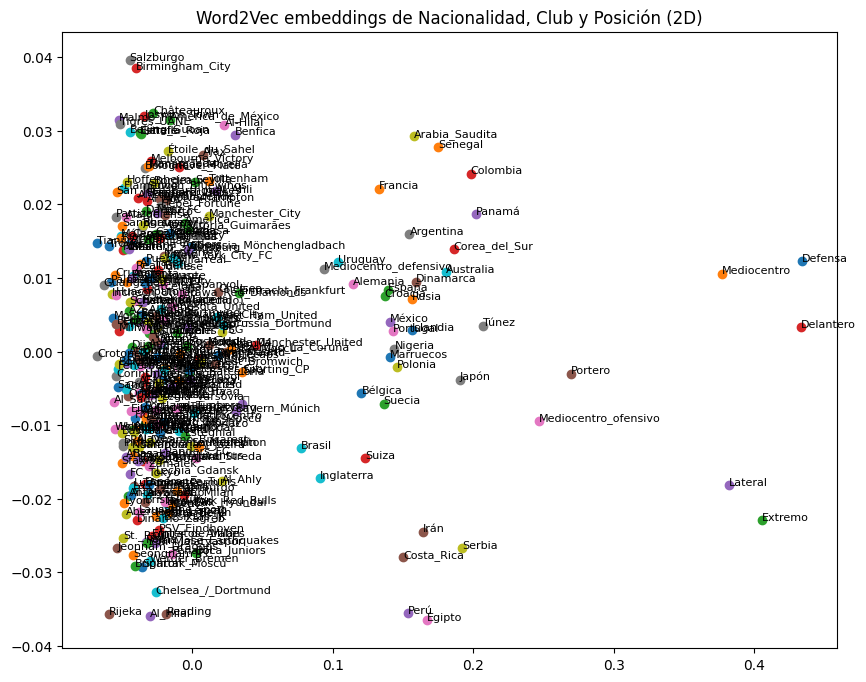

DataFrame para clustering (11 columnas): (604, 11)
✅ Datos normalizados a [0,100]


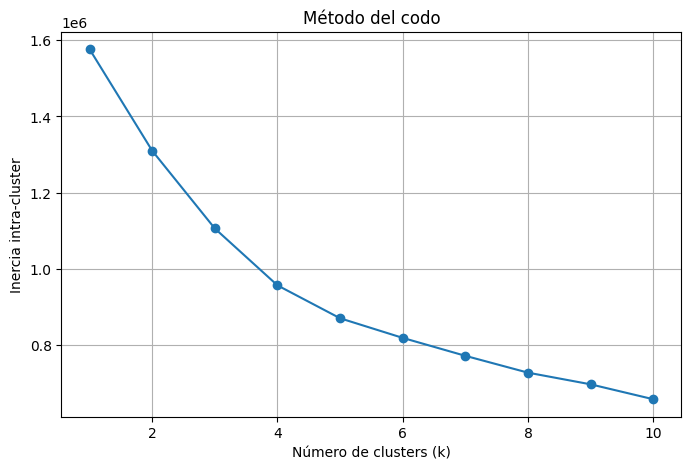

✅ Clustering con k=4 completado.
Distribución de clusters:
 cluster
0    146
1    141
2    267
3     50
Name: count, dtype: int64

🎯 Nuevo jugador asignado al CLUSTER 3


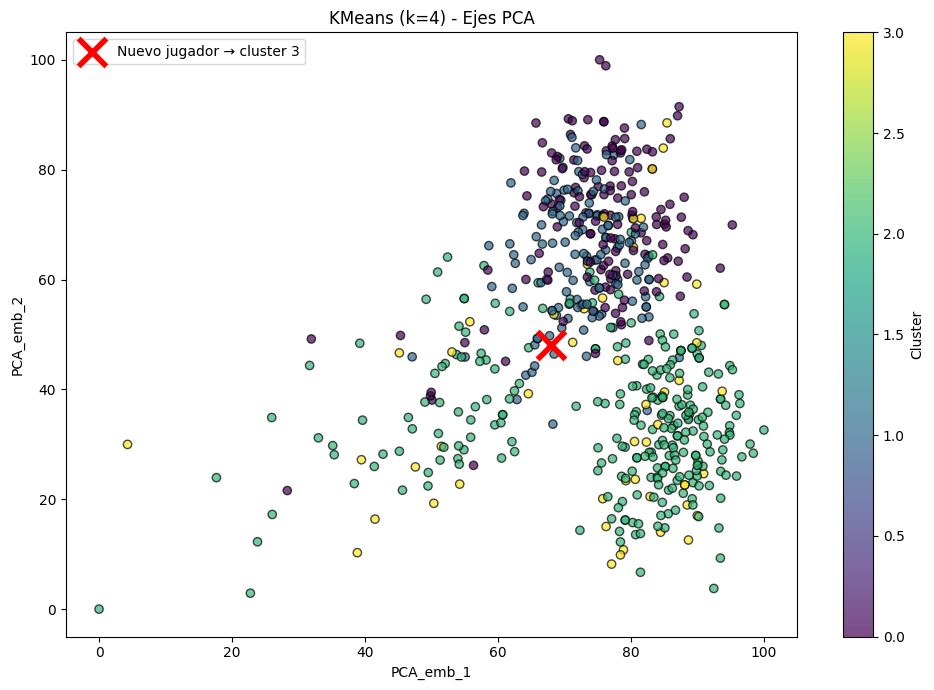


📋 Top 10 jugadores más similares (mismo cluster):
1. Cristiano Ronaldo  (distancia: 73.539)
2. Luis Suárez  (distancia: 86.799)
3. Edinson Cavani  (distancia: 90.309)
4. Robert Lewandowski  (distancia: 94.478)
5. Harry Kane  (distancia: 95.779)
6. Lionel Messi  (distancia: 99.173)
7. Antoine Griezmann  (distancia: 100.423)
8. Romelu Lukaku  (distancia: 100.939)
9. Thomas Müller  (distancia: 102.042)
10. Neymar  (distancia: 104.981)
✓ 'Cristiano Ronaldo' → 'Cristiano Ronaldo dos Santos Aveiro'
✓ 'Luis Suárez' → 'Luis Alberto Suárez Díaz'
✓ 'Edinson Cavani' → 'Edinson Roberto Cavani Gómez'
✓ 'Robert Lewandowski' → 'Robert Lewandowski'
✓ 'Harry Kane' → 'Harry Kane'
✓ 'Lionel Messi' → 'Lionel Andrés Messi Cuccittini'
✓ 'Antoine Griezmann' → 'Antoine Griezmann'
✓ 'Romelu Lukaku' → 'Romelu Lukaku Menama'
✓ 'Thomas Müller' → 'Thomas Müller'
✓ 'Neymar' → 'Neymar da Silva Santos Junior'


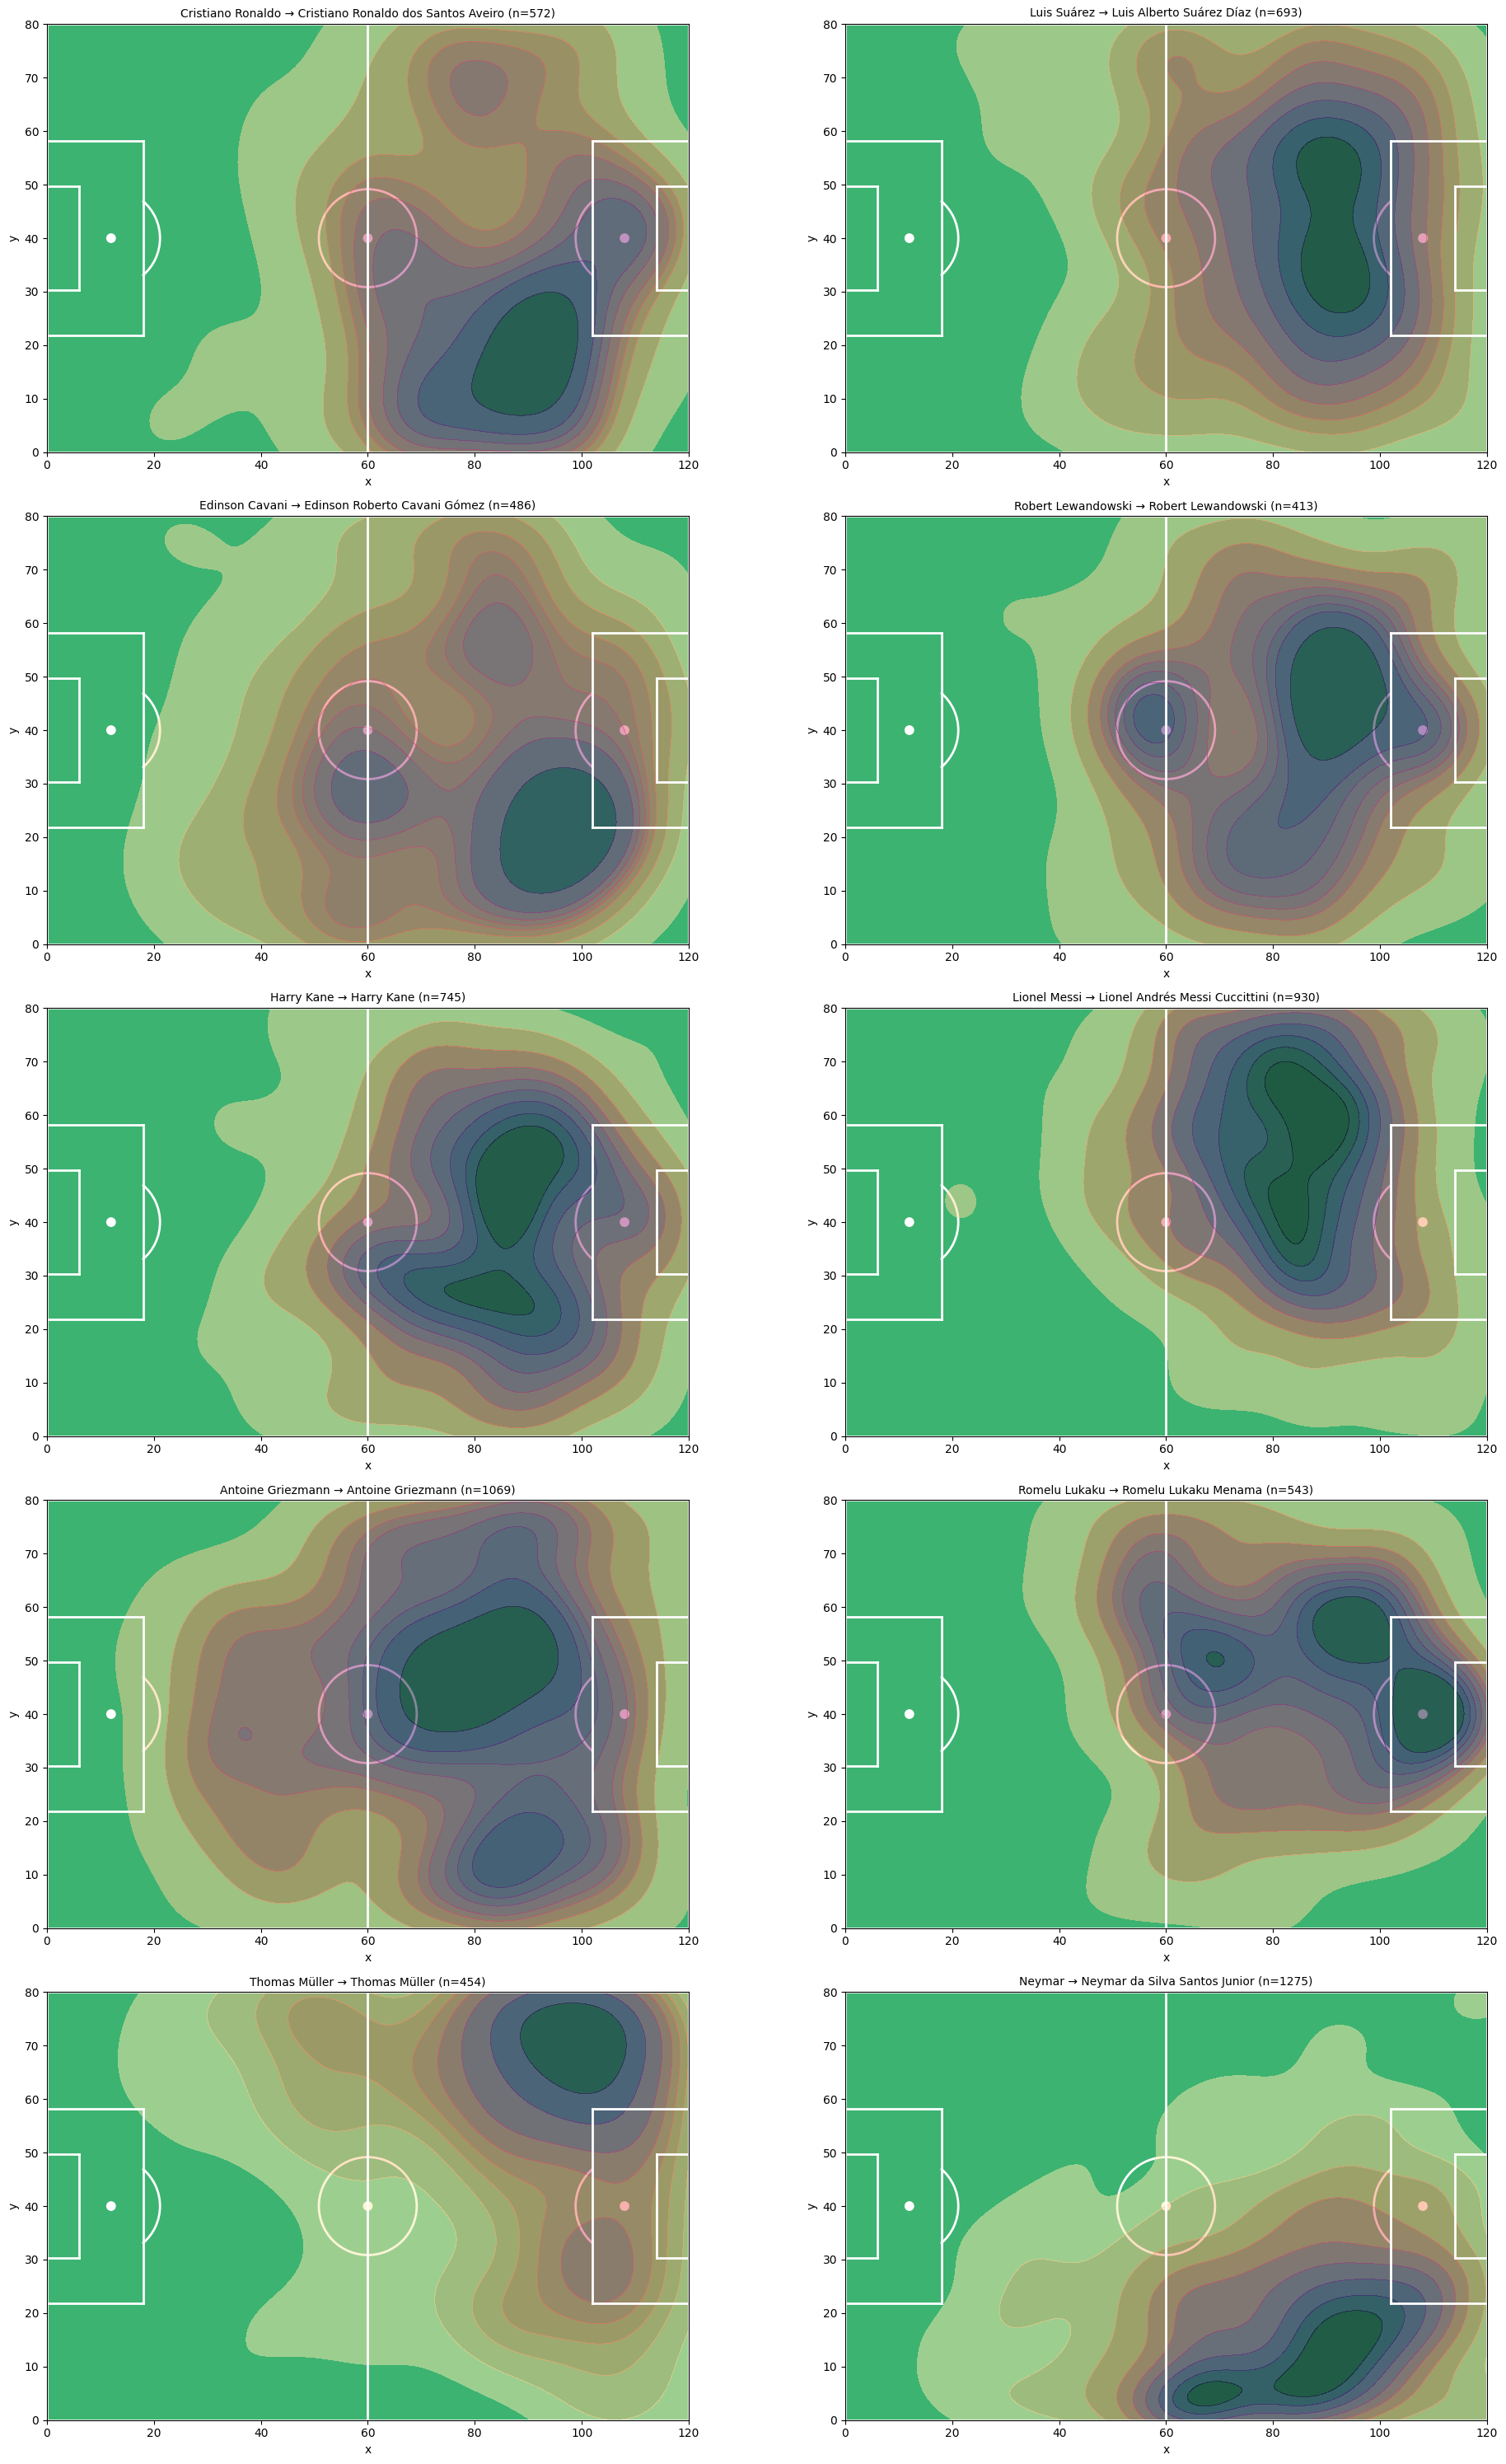


📊 PERFILES MEDIOS POR CLUSTER (0-100):
         PCA_emb_1  PCA_emb_2  PCA_emb_3  Altura  Edad (2018)  \
cluster                                                         
0            75.26      70.03      29.26   31.94        28.66   
1            72.63      63.65      72.67   43.02        33.14   
2            76.69      34.20      46.52   57.71        35.19   
3            73.32      38.07      35.18   36.51        27.77   

         Valor de mercado  Partidos jugados  Goles  Asistencias  Amarillas  \
cluster                                                                      
0                    5.18             55.64  11.25        25.41      40.58   
1                    7.01             59.80   8.38        22.27      50.18   
2                    5.24             56.62   9.89        10.73      42.79   
3                   40.63             80.41  45.91        53.40      53.00   

         Rojas  
cluster         
0         0.00  
1         0.71  
2         1.12  
3         0.00 

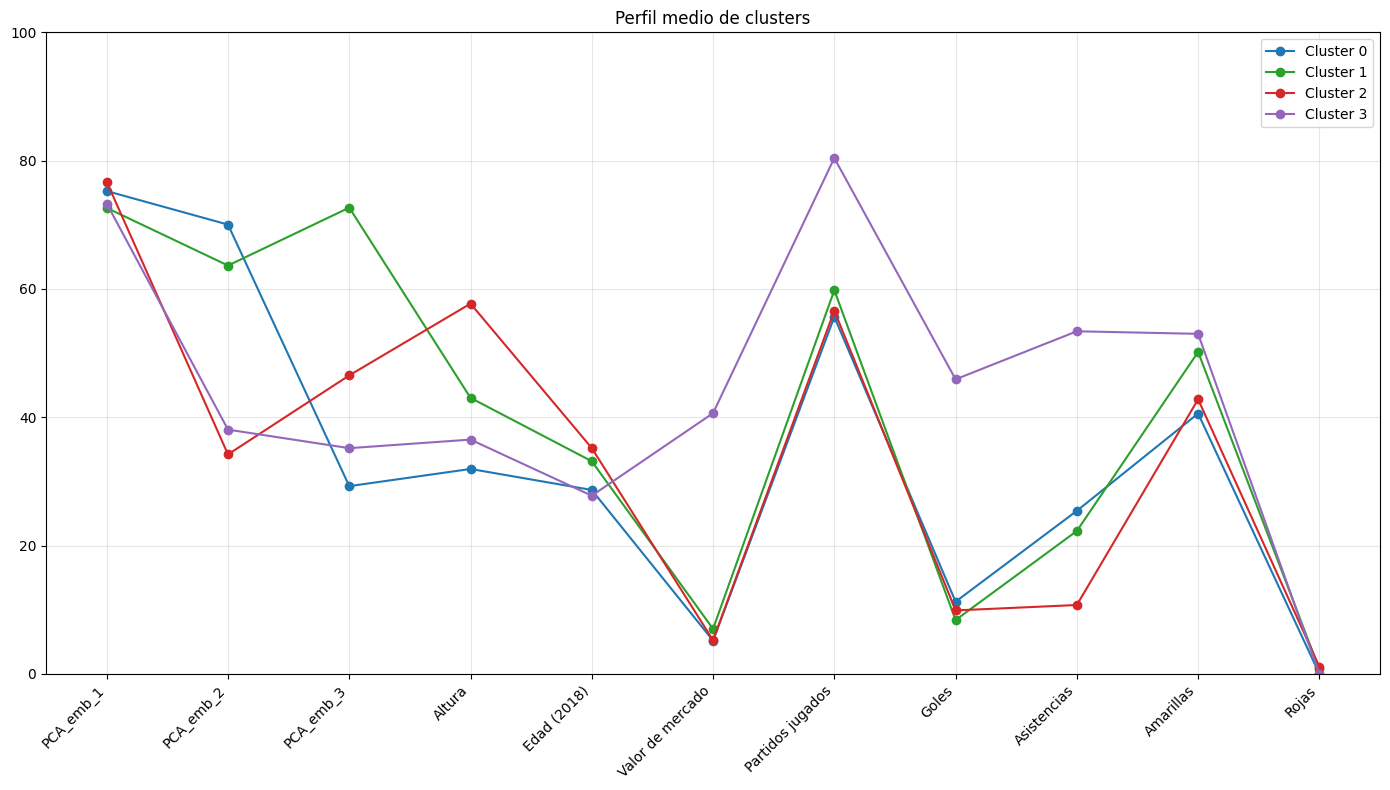

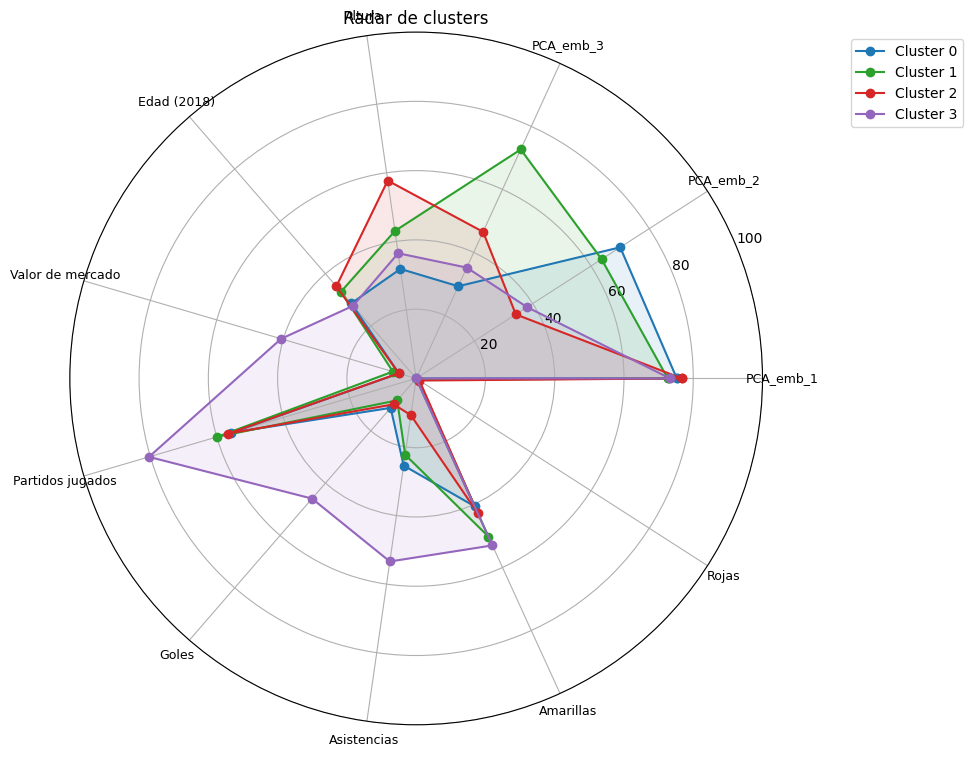

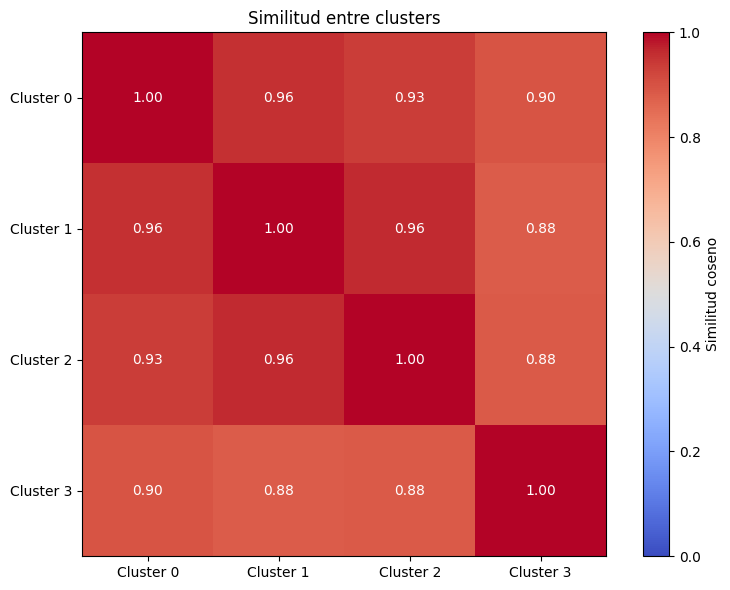


🔍 INTERPRETACIÓN DE CLUSTERS:

📌 Cluster 0 (146 jugadores)
   ▲ Fortalezas: PCA_emb_1 (75), PCA_emb_2 (70), Partidos jugados (56)
   ▼ Debilidades: Rojas (0), Valor de mercado (5), Goles (11)

📌 Cluster 1 (141 jugadores)
   ▲ Fortalezas: PCA_emb_3 (73), PCA_emb_1 (73), PCA_emb_2 (64)
   ▼ Debilidades: Rojas (1), Valor de mercado (7), Goles (8)

📌 Cluster 2 (267 jugadores)
   ▲ Fortalezas: PCA_emb_1 (77), Altura (58), Partidos jugados (57)
   ▼ Debilidades: Rojas (1), Valor de mercado (5), Goles (10)

📌 Cluster 3 (50 jugadores)
   ▲ Fortalezas: Partidos jugados (80), PCA_emb_1 (73), Asistencias (53)
   ▼ Debilidades: Rojas (0), Edad (2018) (28), PCA_emb_3 (35)

✅ Perfiles guardados en 'perfiles_clusters.csv'

🎉 Análisis completo. Puedes modificar los sliders y volver a ejecutar las celdas 8, 9 y 10 para actualizar la predicción y los mapas de calor.


In [2]:
# ============================================================
# NOTEBOOK LIMPIO: CLUSTERING DE FUTBOLISTAS + PREDICCIÓN + MAPAS DE CALOR
# ============================================================

# ============================================================
# 1. INSTALACIÓN DE LIBRERÍAS (solo lo necesario)
# ============================================================
!pip install gensim scikit-learn matplotlib seaborn pandas numpy -q

# ============================================================
# 2. IMPORTACIÓN DE MÓDULOS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from math import pi
import difflib
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 3. MONTAJE DE GOOGLE DRIVE (si los archivos están ahí)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 4. CARGA DE DATOS
# ============================================================
# Archivo principal con estadísticas y embeddings
ruta_principal = "/content/drive/MyDrive/recoleccion de datos.csv"
df = pd.read_csv(ruta_principal, sep=';', encoding='latin1', decimal=',')
print("✅ df (jugadores):", df.shape)

# Archivo de eventos para mapas de calor (coordenadas x,y)
ruta_eventos = '/content/drive/MyDrive/eventos_wc2018_xy_statsbomb.csv'
df_eventos = pd.read_csv(ruta_eventos)
print("✅ df_eventos:", df_eventos.shape)
print("Columnas eventos:", df_eventos.columns.tolist())

# ============================================================
# 5. GENERACIÓN DE EMBEDDINGS CON WORD2VEC (categorías: Nacionalidad, Club, Posición)
# ============================================================
from gensim.models import Word2Vec

# Limpieza de columnas categóricas
col_nac = "Nacionalidad"
col_club = "Club "      # Atención: tiene un espacio al final
col_pos = "Posición"

for col in [col_nac, col_club, col_pos]:
    df[col] = df[col].astype(str).fillna("desconocido").str.strip()
    df[col] = df[col].str.replace(" ", "_")   # reemplazar espacios para Word2Vec

# Crear frases: cada fila es [Nacionalidad, Club, Posición]
frases = df[[col_nac, col_club, col_pos]].values.tolist()

# Entrenar Word2Vec
modelo_w2v = Word2Vec(sentences=frases,
                      vector_size=50,
                      window=2,
                      min_count=1,
                      sg=1,
                      epochs=20,
                      workers=4)

# Función para obtener embedding promedio por fila
def get_embedding_promedio(fila):
    vectores = [modelo_w2v.wv[token] for token in fila if token in modelo_w2v.wv]
    if vectores:
        return np.mean(vectores, axis=0)
    else:
        return np.zeros(modelo_w2v.vector_size)

embeddings_filas = np.array([get_embedding_promedio(fila) for fila in frases])
# Expandir a columnas separadas
emb_df = pd.DataFrame(embeddings_filas, columns=[f'w2v_{i}' for i in range(modelo_w2v.vector_size)])
df = pd.concat([df, emb_df], axis=1)
print("✅ Embeddings generados. df shape:", df.shape)

# (Opcional) Visualización de embeddings de categorías (Word2Vec) - 2D y 3D
categorias = list(modelo_w2v.wv.index_to_key)
vectores_cat = np.array([modelo_w2v.wv[cat] for cat in categorias])
pca_cat = PCA(n_components=2)
vectores_2d = pca_cat.fit_transform(vectores_cat)

plt.figure(figsize=(10,8))
for i, cat in enumerate(categorias):
    plt.scatter(vectores_2d[i,0], vectores_2d[i,1])
    plt.annotate(cat, (vectores_2d[i,0], vectores_2d[i,1]), fontsize=8)
plt.title("Word2Vec embeddings de Nacionalidad, Club y Posición (2D)")
plt.show()

# ============================================================
# 6. PREPARACIÓN DE DATOS PARA CLUSTERING (con limpieza extra)
# ============================================================
# Columnas de embeddings (50) + variables clásicas
embedding_cols = [f'w2v_{i}' for i in range(50)]
clasicas = ['Altura', 'Edad (2018)', 'Valor de mercado', 'Partidos jugados',
            'Goles', 'Asistencias', 'Amarillas', 'Rojas']

# Reducir los 50 embeddings a 3 componentes PCA
pca_emb = PCA(n_components=3)
pca_components = pca_emb.fit_transform(df[embedding_cols])
df_pca = pd.DataFrame(pca_components, columns=['PCA_emb_1', 'PCA_emb_2', 'PCA_emb_3'])

# Unir con las variables clásicas
df_cluster = pd.concat([df_pca, df[clasicas]], axis=1)
print("DataFrame para clustering (11 columnas):", df_cluster.shape)

# --- FUNCIÓN PARA LIMPIAR COLUMNAS CON COMAS ---
def limpiar_columnas_numericas(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            # Eliminar comas, espacios y convertir a número
            df[col] = df[col].astype(str).str.replace(',', '').str.strip()
            df[col] = pd.to_numeric(df[col], errors='coerce')
            # Si hay NaN, rellenar con la media (o 0 si toda la columna es NaN)
            if df[col].isnull().any():
                media = df[col].mean(skipna=True)
                if pd.isna(media):
                    media = 0.0
                df[col] = df[col].fillna(media)
    return df

df_cluster = limpiar_columnas_numericas(df_cluster)

# Normalizar a [0,100]
scaler = MinMaxScaler(feature_range=(0,100))
df_norm = pd.DataFrame(scaler.fit_transform(df_cluster),
                       columns=df_cluster.columns,
                       index=df_cluster.index)
print("✅ Datos normalizados a [0,100]")

# ============================================================
# 7. CLUSTERING KMEANS
# ============================================================
# Método del codo para elegir k
inercia = []
k_range = range(1, 11)
for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(df_norm.values)
    inercia.append(km_temp.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inercia, 'o-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia intra-cluster')
plt.title('Método del codo')
plt.grid(True)
plt.show()

# Elegir k (por ejemplo, 4 según el gráfico)
k_optimo = 4
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_norm.values)
df_norm['cluster'] = cluster_labels
df['cluster'] = cluster_labels   # lo añadimos al dataframe original

print(f"✅ Clustering con k={k_optimo} completado.")
print("Distribución de clusters:\n", df_norm['cluster'].value_counts().sort_index())

# ============================================================
# 8. INTERFAZ DE PREDICCIÓN (SLIDERS) + GRÁFICO PCA + KNN
# ============================================================
# Orden correcto de las 11 características (idéntico al entrenamiento)
orden_features = ['PCA_emb_1', 'PCA_emb_2', 'PCA_emb_3',
                  'Altura', 'Edad (2018)', 'Valor de mercado',
                  'Partidos jugados', 'Goles', 'Asistencias',
                  'Amarillas', 'Rojas']

#@markdown ## Preferencias del nuevo jugador (valores 0-100)
PCA_emb_1 = 68 #@param {type:"slider", min:0, max:100, step:1}
PCA_emb_2 = 48 #@param {type:"slider", min:0, max:100, step:1}
PCA_emb_3 = 61 #@param {type:"slider", min:0, max:100, step:1}
Altura = 79 #@param {type:"slider", min:0, max:100, step:1}
Edad_2018 = 81 #@param {type:"slider", min:0, max:100, step:1}
Valor_mercado = 84 #@param {type:"slider", min:0, max:100, step:1}
Partidos = 86 #@param {type:"slider", min:0, max:100, step:1}
Goles = 92 #@param {type:"slider", min:0, max:100, step:1}
Asistencias = 77 #@param {type:"slider", min:0, max:100, step:1}
Amarillas = 34 #@param {type:"slider", min:0, max:100, step:1}
Rojas = 30 #@param {type:"slider", min:0, max:100, step:1}

nuevo_jugador = np.array([[PCA_emb_1, PCA_emb_2, PCA_emb_3, Altura, Edad_2018,
                           Valor_mercado, Partidos, Goles, Asistencias, Amarillas, Rojas]])

# Predecir cluster
cluster_nuevo = kmeans.predict(nuevo_jugador)[0]
print(f"\n🎯 Nuevo jugador asignado al CLUSTER {cluster_nuevo}")

# Gráfico PCA (solo las dos primeras componentes)
plt.figure(figsize=(10,7))
scatter = plt.scatter(df_norm['PCA_emb_1'], df_norm['PCA_emb_2'],
                      c=df_norm['cluster'], cmap='viridis', alpha=0.7, edgecolors='k')
plt.colorbar(scatter, label='Cluster')
plt.scatter(nuevo_jugador[0,0], nuevo_jugador[0,1], marker='x', color='red', s=400, linewidths=4,
            label=f'Nuevo jugador → cluster {cluster_nuevo}')
plt.xlabel('PCA_emb_1'); plt.ylabel('PCA_emb_2')
plt.title(f'KMeans (k={k_optimo}) - Ejes PCA')
plt.legend(); plt.tight_layout(); plt.show()

# KNN: vecinos más cercanos dentro del mismo cluster
df_mismo_cluster = df_norm[df_norm['cluster'] == cluster_nuevo].copy()
X_cluster = df_mismo_cluster[orden_features].values
knn = NearestNeighbors(n_neighbors=min(10, len(X_cluster)), metric='euclidean')
knn.fit(X_cluster)
distancias, indices_locales = knn.kneighbors(nuevo_jugador)
indices_globales = df_mismo_cluster.iloc[indices_locales[0]].index.tolist()

print("\n📋 Top 10 jugadores más similares (mismo cluster):")
for i, idx in enumerate(indices_globales):
    nombre = df.loc[idx, 'Nombre']
    print(f"{i+1}. {nombre}  (distancia: {distancias[0][i]:.3f})")

# ============================================================
# 9. MAPAS DE CALOR EN EL CAMPO PARA ESOS JUGADORES (usando df_eventos)
# ============================================================
def encontrar_mejor_match(nombre_buscar, lista_nombres, umbral=0.4):
    nombre_buscar_norm = nombre_buscar.strip().lower()
    norm_dict = {nom: nom.strip().lower() for nom in lista_nombres}
    for orig, norm in norm_dict.items():
        if norm == nombre_buscar_norm:
            return orig
    for orig, norm in norm_dict.items():
        if nombre_buscar_norm in norm:
            return orig
    for orig, norm in norm_dict.items():
        if norm.startswith(nombre_buscar_norm):
            return orig
    matches = difflib.get_close_matches(nombre_buscar_norm, list(norm_dict.values()), n=1, cutoff=umbral)
    if matches:
        for orig, norm in norm_dict.items():
            if norm == matches[0]:
                return orig
    return None

# Obtener nombres de los vecinos
nombres_vecinos = [df.loc[idx, 'Nombre'] for idx in indices_globales]
nombres_disponibles = df_eventos['jugador'].unique().tolist()

matches_validos = []
for nb in nombres_vecinos:
    match = encontrar_mejor_match(nb, nombres_disponibles, umbral=0.4)
    if match:
        matches_validos.append((nb, match))
        print(f"✓ '{nb}' → '{match}'")
    else:
        print(f"✗ '{nb}' → no encontrado en eventos")

pitch_width, pitch_height = 120, 80
n_plots = min(len(matches_validos), 10)

if n_plots > 0:
    fig, axes = plt.subplots(5, 2, figsize=(20, 30))
    axes = axes.flatten()
    for i, (nombre_orig, nombre_match) in enumerate(matches_validos[:10]):
        ax = axes[i]
        player_df = df_eventos[df_eventos['jugador'] == nombre_match].copy()
        player_df = player_df[(player_df['x'] >= 0) & (player_df['x'] <= pitch_width) &
                              (player_df['y'] >= 0) & (player_df['y'] <= pitch_height)]

        # Dibujar campo
        ax.set_facecolor('mediumseagreen')
        # Líneas exteriores
        ax.plot([0,0], [0,pitch_height], 'w', lw=2)
        ax.plot([0,pitch_width], [pitch_height,pitch_height], 'w', lw=2)
        ax.plot([pitch_width,pitch_width], [pitch_height,0], 'w', lw=2)
        ax.plot([pitch_width,0], [0,0], 'w', lw=2)
        # Media cancha
        ax.plot([pitch_width/2, pitch_width/2], [0, pitch_height], 'w', lw=2)
        # Círculo central
        ax.add_patch(patches.Circle((pitch_width/2, pitch_height/2), 9.15, color='w', fill=False, lw=2))
        ax.add_patch(patches.Circle((pitch_width/2, pitch_height/2), 0.8, color='w'))
        # Áreas de penal
        ax.plot([18,18], [21.8, pitch_height-21.8], 'w', lw=2)
        ax.plot([0,18], [21.8,21.8], 'w', lw=2)
        ax.plot([0,18], [pitch_height-21.8, pitch_height-21.8], 'w', lw=2)
        ax.plot([pitch_width-18, pitch_width-18], [21.8, pitch_height-21.8], 'w', lw=2)
        ax.plot([pitch_width-18, pitch_width], [21.8,21.8], 'w', lw=2)
        ax.plot([pitch_width-18, pitch_width], [pitch_height-21.8, pitch_height-21.8], 'w', lw=2)
        # Áreas pequeñas (6 yardas)
        ax.plot([6,6], [30.34, pitch_height-30.34], 'w', lw=2)
        ax.plot([0,6], [30.34,30.34], 'w', lw=2)
        ax.plot([0,6], [pitch_height-30.34, pitch_height-30.34], 'w', lw=2)
        ax.plot([pitch_width-6, pitch_width-6], [30.34, pitch_height-30.34], 'w', lw=2)
        ax.plot([pitch_width-6, pitch_width], [30.34,30.34], 'w', lw=2)
        ax.plot([pitch_width-6, pitch_width], [pitch_height-30.34, pitch_height-30.34], 'w', lw=2)
        # Puntos de penal y arcos
        ax.add_patch(patches.Circle((12, pitch_height/2), 0.8, color='w'))
        ax.add_patch(patches.Circle((pitch_width-12, pitch_height/2), 0.8, color='w'))
        ax.add_patch(patches.Arc((12, pitch_height/2), 18.3, 18.3, theta1=310, theta2=50, color='w', lw=2))
        ax.add_patch(patches.Arc((pitch_width-12, pitch_height/2), 18.3, 18.3, theta1=130, theta2=230, color='w', lw=2))

        # Mapa de calor
        if len(player_df) >= 3:
            sns.kdeplot(x='x', y='y', data=player_df, cmap='magma_r', fill=True, alpha=0.5, ax=ax, warn_singular=False)
        else:
            ax.scatter(player_df['x'], player_df['y'], c='cyan', s=10, alpha=0.8)

        ax.set_title(f'{nombre_orig} → {nombre_match} (n={len(player_df)})', fontsize=10)
        ax.set_xlim(0, pitch_width); ax.set_ylim(0, pitch_height)
        ax.set_aspect('equal'); ax.grid(False)

    for j in range(n_plots, 10):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron coincidencias para generar mapas de calor.")

# ============================================================
# 10. PERFILES DE CLUSTERS (LÍNEAS, RADAR, SIMILITUD, INTERPRETACIÓN)
# ============================================================
perfiles = df_norm.groupby('cluster')[orden_features].mean()

print("\n📊 PERFILES MEDIOS POR CLUSTER (0-100):")
print(perfiles.round(2))

# Líneas paralelas
plt.figure(figsize=(14,8))
colores = ['#1f77b4','#2ca02c','#d62728','#9467bd']
for i, cid in enumerate(sorted(perfiles.index)):
    plt.plot(orden_features, perfiles.loc[cid].values, 'o-', label=f'Cluster {cid}', color=colores[i])
plt.xticks(rotation=45, ha='right'); plt.ylim(0,100); plt.grid(True, alpha=0.3)
plt.title('Perfil medio de clusters'); plt.legend(); plt.tight_layout(); plt.show()

# Radar
def radar_plot(perfiles, columnas, colores):
    n_vars = len(columnas)
    angulos = [n / n_vars * 2 * pi for n in range(n_vars)] + [0]
    fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(projection='polar'))
    for i, cid in enumerate(sorted(perfiles.index)):
        valores = perfiles.loc[cid].values.flatten().tolist() + [perfiles.loc[cid].values[0]]
        ax.plot(angulos, valores, 'o-', color=colores[i%len(colores)], label=f'Cluster {cid}')
        ax.fill(angulos, valores, alpha=0.1, color=colores[i%len(colores)])
    ax.set_xticks(angulos[:-1]); ax.set_xticklabels(columnas, size=9, rotation=45)
    ax.set_ylim(0,100); ax.set_title('Radar de clusters'); ax.legend(loc='upper right', bbox_to_anchor=(1.3,1))
    plt.tight_layout(); plt.show()

radar_plot(perfiles, orden_features, colores)

# Matriz de similitud coseno
similitud = cosine_similarity(perfiles)
plt.figure(figsize=(8,6))
plt.imshow(similitud, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(label='Similitud coseno')
plt.xticks(range(len(perfiles)), [f'Cluster {i}' for i in sorted(perfiles.index)])
plt.yticks(range(len(perfiles)), [f'Cluster {i}' for i in sorted(perfiles.index)])
for i in range(len(perfiles)):
    for j in range(len(perfiles)):
        plt.text(j, i, f'{similitud[i,j]:.2f}', ha='center', va='center',
                 color='black' if similitud[i,j] < 0.5 else 'white')
plt.title('Similitud entre clusters'); plt.tight_layout(); plt.show()

# Interpretación automática
print("\n🔍 INTERPRETACIÓN DE CLUSTERS:")
for cid in sorted(perfiles.index):
    valores = perfiles.loc[cid]
    top3 = valores.nlargest(3); bottom3 = valores.nsmallest(3)
    n_jug = len(df_norm[df_norm['cluster']==cid])
    print(f"\n📌 Cluster {cid} ({n_jug} jugadores)")
    print(f"   ▲ Fortalezas: {', '.join([f'{v} ({valores[v]:.0f})' for v in top3.index])}")
    print(f"   ▼ Debilidades: {', '.join([f'{v} ({valores[v]:.0f})' for v in bottom3.index])}")

# Exportar resultados (opcional)
perfiles.to_csv('perfiles_clusters.csv')
print("\n✅ Perfiles guardados en 'perfiles_clusters.csv'")

print("\n🎉 Análisis completo. Puedes modificar los sliders y volver a ejecutar las celdas 8, 9 y 10 para actualizar la predicción y los mapas de calor.")

In [ ]:
print("Varianza explicada por las 3 primeras componentes:", pca_emb.explained_variance_ratio_.sum())

Varianza explicada por las 3 primeras componentes: 0.37133542


In [ ]:
!pip install scikit-fuzzy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.8 MB/s eta 0:00:00


In [ ]:
import skfuzzy as fuzz

# Preparar datos: matriz de características (604 × 11)
X_fcm = df_norm[orden_features].values.T  # FCM espera (n_features, n_samples)

# Número de clústeres (debe coincidir con el de K-means)
n_clusters = 4
m = 2  # parámetro de difusidad

# Ejecutar Fuzzy C-means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_fcm,
    c=n_clusters,
    m=m,
    error=0.005,
    maxiter=1000,
    init=None
)

# `u` tiene forma (n_clusters, n_samples)
# Obtener el clúster dominante (máxima pertenencia) para cada jugador
cluster_fuzzy_dominante = np.argmax(u, axis=0)

# Añadir al DataFrame
df_norm['cluster_fuzzy'] = cluster_fuzzy_dominante

In [ ]:
from sklearn.metrics import adjusted_rand_score, confusion_matrix
import pandas as pd

# Asegurar que tienes cluster_labels de K-means
# Si ya lo tienes, puedes usarlo. Si no, recuperarlo:
# cluster_labels_kmeans = kmeans.labels_  # o df_norm['cluster'].values

# Tabla de contingencia
tabla = pd.crosstab(df_norm['cluster'], df_norm['cluster_fuzzy'])
print("📊 Tabla de contingencia (K-means vs Fuzzy C-means):")
print(tabla)

# Índice de Rand ajustado (mide la concordancia)
ari = adjusted_rand_score(df_norm['cluster'], df_norm['cluster_fuzzy'])
print(f"\n🔗 Índice de Rand ajustado: {ari:.3f}")

📊 Tabla de contingencia (K-means vs Fuzzy C-means):
cluster_fuzzy   0   1    2    3
cluster                        
0               0   0  146    0
1              32  32   61   16
2              11   6    4  246
3               9   3   29    9

🔗 Índice de Rand ajustado: 0.560


In [ ]:
# ============================================================
# SISTEMA DE RECOMENDACIÓN DE PLANIFICACIÓN DEPORTIVA COLABORATIVA DIFUSA
# SCRIPT COMPLETO: GENERA UN ÚNICO PDF CON TODOS LOS REPORTES
# ============================================================

# ============================================================
# 1. INSTALACIÓN DE LIBRERÍAS (solo lo necesario)
# ============================================================
!pip install gensim scikit-learn matplotlib seaborn pandas numpy -q

# ============================================================
# 2. IMPORTACIÓN DE MÓDULOS
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from math import pi
import difflib
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive, files
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

# ============================================================
# 3. MONTAJE DE GOOGLE DRIVE
# ============================================================
drive.mount('/content/drive')

# ============================================================
# 4. CARGA DE DATOS
# ============================================================
ruta_principal = "/content/drive/MyDrive/recoleccion de datos.csv"
df = pd.read_csv(ruta_principal, sep=';', encoding='latin1', decimal=',')
print("✅ df (jugadores):", df.shape)

ruta_eventos = '/content/drive/MyDrive/eventos_wc2018_xy_statsbomb.csv'
df_eventos = pd.read_csv(ruta_eventos)
print("✅ df_eventos:", df_eventos.shape)

# ============================================================
# 5. GENERACIÓN DE EMBEDDINGS CON WORD2VEC
# ============================================================
from gensim.models import Word2Vec

col_nac = "Nacionalidad"
col_club = "Club "
col_pos = "Posición"

for col in [col_nac, col_club, col_pos]:
    df[col] = df[col].astype(str).fillna("desconocido").str.strip()
    df[col] = df[col].str.replace(" ", "_")

frases = df[[col_nac, col_club, col_pos]].values.tolist()
modelo_w2v = Word2Vec(sentences=frases,
                      vector_size=50,
                      window=2,
                      min_count=1,
                      sg=1,
                      epochs=20,
                      workers=4)

def get_embedding_promedio(fila):
    vectores = [modelo_w2v.wv[token] for token in fila if token in modelo_w2v.wv]
    if vectores:
        return np.mean(vectores, axis=0)
    else:
        return np.zeros(modelo_w2v.vector_size)

embeddings_filas = np.array([get_embedding_promedio(fila) for fila in frases])
emb_df = pd.DataFrame(embeddings_filas, columns=[f'w2v_{i}' for i in range(modelo_w2v.vector_size)])
df = pd.concat([df, emb_df], axis=1)
print("✅ Embeddings generados. df shape:", df.shape)

# ============================================================
# 6. PREPARACIÓN DE DATOS PARA CLUSTERING
# ============================================================
embedding_cols = [f'w2v_{i}' for i in range(50)]
clasicas = ['Altura', 'Edad (2018)', 'Valor de mercado', 'Partidos jugados',
            'Goles', 'Asistencias', 'Amarillas', 'Rojas']

pca_emb = PCA(n_components=3)
pca_components = pca_emb.fit_transform(df[embedding_cols])
df_pca = pd.DataFrame(pca_components, columns=['PCA_emb_1', 'PCA_emb_2', 'PCA_emb_3'])
df_cluster = pd.concat([df_pca, df[clasicas]], axis=1)

def limpiar_columnas_numericas(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '').str.strip()
            df[col] = pd.to_numeric(df[col], errors='coerce')
            if df[col].isnull().any():
                media = df[col].mean(skipna=True)
                if pd.isna(media):
                    media = 0.0
                df[col] = df[col].fillna(media)
    return df

df_cluster = limpiar_columnas_numericas(df_cluster)
scaler = MinMaxScaler(feature_range=(0,100))
df_norm = pd.DataFrame(scaler.fit_transform(df_cluster),
                       columns=df_cluster.columns,
                       index=df_cluster.index)
print("✅ Datos normalizados a [0,100]")

# ============================================================
# 7. CLUSTERING KMEANS + MÉTODO DEL CODO
# ============================================================
inercia = []
k_range = range(1, 11)
for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(df_norm.values)
    inercia.append(km_temp.inertia_)

k_optimo = 4
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_norm.values)
df_norm['cluster'] = cluster_labels
df['cluster'] = cluster_labels
print(f"✅ Clustering con k={k_optimo} completado.")

# ============================================================
# 8. DEFINIR PERFIL OBJETIVO (sliders)
# ============================================================
orden_features = ['PCA_emb_1', 'PCA_emb_2', 'PCA_emb_3',
                  'Altura', 'Edad (2018)', 'Valor de mercado',
                  'Partidos jugados', 'Goles', 'Asistencias',
                  'Amarillas', 'Rojas']

#@markdown ## Preferencias del nuevo jugador (valores 0-100)
PCA_emb_1 = 68 #@param {type:"slider", min:0, max:100, step:1}
PCA_emb_2 = 48 #@param {type:"slider", min:0, max:100, step:1}
PCA_emb_3 = 61 #@param {type:"slider", min:0, max:100, step:1}
Altura = 79 #@param {type:"slider", min:0, max:100, step:1}
Edad_2018 = 81 #@param {type:"slider", min:0, max:100, step:1}
Valor_mercado = 84 #@param {type:"slider", min:0, max:100, step:1}
Partidos = 86 #@param {type:"slider", min:0, max:100, step:1}
Goles = 92 #@param {type:"slider", min:0, max:100, step:1}
Asistencias = 77 #@param {type:"slider", min:0, max:100, step:1}
Amarillas = 34 #@param {type:"slider", min:0, max:100, step:1}
Rojas = 30 #@param {type:"slider", min:0, max:100, step:1}

nuevo_jugador = np.array([[PCA_emb_1, PCA_emb_2, PCA_emb_3, Altura, Edad_2018,
                           Valor_mercado, Partidos, Goles, Asistencias, Amarillas, Rojas]])

cluster_nuevo = kmeans.predict(nuevo_jugador)[0]
print(f"🎯 Nuevo jugador asignado al CLUSTER {cluster_nuevo}")

# KNN: vecinos más cercanos
df_mismo_cluster = df_norm[df_norm['cluster'] == cluster_nuevo].copy()
X_cluster = df_mismo_cluster[orden_features].values
knn = NearestNeighbors(n_neighbors=min(10, len(X_cluster)), metric='euclidean')
knn.fit(X_cluster)
distancias, indices_locales = knn.kneighbors(nuevo_jugador)
indices_globales = df_mismo_cluster.iloc[indices_locales[0]].index.tolist()
nombres_vecinos = [df.loc[idx, 'Nombre'] for idx in indices_globales]

print("\n📋 Top 10 jugadores más similares:")
for i, nombre in enumerate(nombres_vecinos):
    print(f"{i+1}. {nombre}  (distancia: {distancias[0][i]:.3f})")

# ============================================================
# 9. MAPAS DE CALOR PARA VECINOS
# ============================================================
def encontrar_mejor_match(nombre_buscar, lista_nombres, umbral=0.4):
    nombre_buscar_norm = nombre_buscar.strip().lower()
    norm_dict = {nom: nom.strip().lower() for nom in lista_nombres}
    for orig, norm in norm_dict.items():
        if norm == nombre_buscar_norm:
            return orig
    for orig, norm in norm_dict.items():
        if nombre_buscar_norm in norm:
            return orig
    for orig, norm in norm_dict.items():
        if norm.startswith(nombre_buscar_norm):
            return orig
    matches = difflib.get_close_matches(nombre_buscar_norm, list(norm_dict.values()), n=1, cutoff=umbral)
    if matches:
        for orig, norm in norm_dict.items():
            if norm == matches[0]:
                return orig
    return None

nombres_disponibles = df_eventos['jugador'].unique().tolist()
matches_validos = []
for nb in nombres_vecinos:
    match = encontrar_mejor_match(nb, nombres_disponibles, umbral=0.4)
    if match:
        matches_validos.append((nb, match))

pitch_width, pitch_height = 120, 80
n_plots = min(len(matches_validos), 10)

# ============================================================
# 10. PERFILES DE CLUSTERS
# ============================================================
perfiles = df_norm.groupby('cluster')[orden_features].mean()
similitud = cosine_similarity(perfiles)

# ============================================================
# 11. GENERAR PDF ÚNICO CON TODOS LOS REPORTES
# ============================================================
pdf_filename = f"Reporte_Completo_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
with PdfPages(pdf_filename) as pdf:

    # --- PÁGINA 1: PORTADA / TÍTULO ---
    fig, ax = plt.subplots(figsize=(11.69, 8.27))  # A4 horizontal
    ax.axis('off')
    ax.text(0.5, 0.85, "SISTEMA DE RECOMENDACIÓN DE PLANIFICACIÓN", ha='center', fontsize=22, weight='bold')
    ax.text(0.5, 0.78, "DEPORTIVA COLABORATIVA DIFUSA", ha='center', fontsize=22, weight='bold')
    ax.text(0.5, 0.65, "Reporte completo de análisis", ha='center', fontsize=16)
    ax.text(0.5, 0.55, f"Fecha: {datetime.now().strftime('%d/%m/%Y %H:%M')}", ha='center', fontsize=12)
    ax.text(0.5, 0.48, f"Jugadores analizados: {len(df_norm)}", ha='center', fontsize=12)
    ax.text(0.5, 0.42, f"Número de clusters: {k_optimo}", ha='center', fontsize=12)
    ax.text(0.5, 0.35, "Universidad Técnica de Manabí", ha='center', fontsize=14, style='italic')
    ax.text(0.5, 0.28, "Carrera de Estadística", ha='center', fontsize=12)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- PÁGINA 2: MÉTODO DEL CODO ---
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    ax.plot(k_range, inercia, 'o-', linewidth=2)
    ax.set_xlabel('Número de clusters (k)')
    ax.set_ylabel('Inercia intra-cluster (WSS)')
    ax.set_title('Método del codo para determinación de k')
    ax.grid(True, alpha=0.3)
    ax.annotate(f'k = {k_optimo}', xy=(k_optimo, inercia[k_optimo-1]),
                xytext=(k_optimo+1, inercia[k_optimo-1]*0.7),
                arrowprops=dict(facecolor='red', shrink=0.05))
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- PÁGINA 3: GRÁFICO PCA ---
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    scatter = ax.scatter(df_norm['PCA_emb_1'], df_norm['PCA_emb_2'],
                         c=df_norm['cluster'], cmap='viridis', alpha=0.7, edgecolors='k', s=40)
    ax.scatter(nuevo_jugador[0,0], nuevo_jugador[0,1],
               marker='x', color='red', s=400, linewidths=4,
               label=f'Nuevo jugador → cluster {cluster_nuevo}')
    ax.set_xlabel('PCA_emb_1')
    ax.set_ylabel('PCA_emb_2')
    ax.set_title('Proyección PCA de los jugadores')
    ax.legend()
    plt.colorbar(scatter, ax=ax, label='Cluster')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- PÁGINA 4: TABLA DE VECINOS ---
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    ax.axis('tight')
    ax.axis('off')
    table_data = [[i+1, nombres_vecinos[i], f"{distancias[0][i]:.3f}"] for i in range(len(nombres_vecinos))]
    table = ax.table(cellText=table_data,
                     colLabels=['#', 'Jugador', 'Distancia'],
                     loc='center',
                     cellLoc='center',
                     colWidths=[0.1, 0.6, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    ax.set_title('Top 10 jugadores más similares', fontsize=16, pad=30)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- PÁGINA 5: PERFILES MEDIOS (tabla) ---
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    ax.axis('tight')
    ax.axis('off')
    table_data = perfiles.round(2).values.tolist()
    col_labels = ['Cluster'] + list(perfiles.columns)
    table_rows = [[f'Cluster {i}'] + row for i, row in enumerate(table_data)]
    table = ax.table(cellText=table_rows,
                     colLabels=col_labels,
                     loc='center',
                     cellLoc='center',
                     colWidths=[0.1] + [0.08]*11)
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.5)
    ax.set_title('Perfiles medios por cluster', fontsize=16, pad=30)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- PÁGINA 6: LÍNEAS PARALELAS ---
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    colores = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']
    for i, cid in enumerate(sorted(perfiles.index)):
        ax.plot(orden_features, perfiles.loc[cid].values,
                'o-', label=f'Cluster {cid}', color=colores[i], linewidth=2)
    ax.set_xticks(range(len(orden_features)))
    ax.set_xticklabels(orden_features, rotation=45, ha='right')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Valor medio (0-100)')
    ax.set_title('Perfil medio de clusters (líneas paralelas)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- PÁGINA 7: RADAR ---
    fig, ax = plt.subplots(figsize=(11.69, 8.27), subplot_kw=dict(projection='polar'))
    n_vars = len(orden_features)
    angulos = [n / n_vars * 2 * pi for n in range(n_vars)] + [0]
    for i, cid in enumerate(sorted(perfiles.index)):
        valores = perfiles.loc[cid].values.flatten().tolist() + [perfiles.loc[cid].values[0]]
        ax.plot(angulos, valores, 'o-', color=colores[i % len(colores)], label=f'Cluster {cid}', linewidth=2)
        ax.fill(angulos, valores, alpha=0.1, color=colores[i % len(colores)])
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(orden_features, size=9, rotation=45)
    ax.set_ylim(0, 100)
    ax.set_title('Radar de clusters', size=16, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- PÁGINA 8: MATRIZ DE SIMILITUD ---
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    im = ax.imshow(similitud, cmap='coolwarm', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Similitud coseno')
    ax.set_xticks(range(len(perfiles)))
    ax.set_yticks(range(len(perfiles)))
    ax.set_xticklabels([f'Cluster {i}' for i in sorted(perfiles.index)])
    ax.set_yticklabels([f'Cluster {i}' for i in sorted(perfiles.index)])
    for i in range(len(perfiles)):
        for j in range(len(perfiles)):
            ax.text(j, i, f'{similitud[i, j]:.2f}', ha='center', va='center',
                    color='black' if similitud[i, j] < 0.5 else 'white')
    ax.set_title('Similitud entre clusters (coseno)')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- PÁGINA 9-10: MAPAS DE CALOR ---
    if n_plots > 0:
        fig, axes = plt.subplots(5, 2, figsize=(11.69, 16.54))
        axes = axes.flatten()
        for i, (nombre_orig, nombre_match) in enumerate(matches_validos[:10]):
            ax = axes[i]
            player_df = df_eventos[df_eventos['jugador'] == nombre_match].copy()
            player_df = player_df[(player_df['x'] >= 0) & (player_df['x'] <= pitch_width) &
                                  (player_df['y'] >= 0) & (player_df['y'] <= pitch_height)]
            ax.set_facecolor('mediumseagreen')
            ax.plot([0,0], [0,pitch_height], 'w', lw=1)
            ax.plot([0,pitch_width], [pitch_height,pitch_height], 'w', lw=1)
            ax.plot([pitch_width,pitch_width], [pitch_height,0], 'w', lw=1)
            ax.plot([pitch_width,0], [0,0], 'w', lw=1)
            ax.plot([pitch_width/2, pitch_width/2], [0, pitch_height], 'w', lw=1)
            ax.add_patch(patches.Circle((pitch_width/2, pitch_height/2), 9.15, color='w', fill=False, lw=1))
            ax.add_patch(patches.Circle((pitch_width/2, pitch_height/2), 0.8, color='w'))
            ax.plot([18,18], [21.8, pitch_height-21.8], 'w', lw=1)
            ax.plot([0,18], [21.8,21.8], 'w', lw=1)
            ax.plot([0,18], [pitch_height-21.8, pitch_height-21.8], 'w', lw=1)
            ax.plot([pitch_width-18, pitch_width-18], [21.8, pitch_height-21.8], 'w', lw=1)
            ax.plot([pitch_width-18, pitch_width], [21.8,21.8], 'w', lw=1)
            ax.plot([pitch_width-18, pitch_width], [pitch_height-21.8, pitch_height-21.8], 'w', lw=1)
            ax.plot([6,6], [30.34, pitch_height-30.34], 'w', lw=1)
            ax.plot([0,6], [30.34,30.34], 'w', lw=1)
            ax.plot([0,6], [pitch_height-30.34, pitch_height-30.34], 'w', lw=1)
            ax.plot([pitch_width-6, pitch_width-6], [30.34, pitch_height-30.34], 'w', lw=1)
            ax.plot([pitch_width-6, pitch_width], [30.34,30.34], 'w', lw=1)
            ax.plot([pitch_width-6, pitch_width], [pitch_height-30.34, pitch_height-30.34], 'w', lw=1)
            ax.add_patch(patches.Circle((12, pitch_height/2), 0.8, color='w'))
            ax.add_patch(patches.Circle((pitch_width-12, pitch_height/2), 0.8, color='w'))
            ax.add_patch(patches.Arc((12, pitch_height/2), 18.3, 18.3, theta1=310, theta2=50, color='w', lw=1))
            ax.add_patch(patches.Arc((pitch_width-12, pitch_height/2), 18.3, 18.3, theta1=130, theta2=230, color='w', lw=1))
            if len(player_df) >= 3:
                sns.kdeplot(x='x', y='y', data=player_df, cmap='magma_r', fill=True, alpha=0.5, ax=ax, warn_singular=False)
            else:
                ax.scatter(player_df['x'], player_df['y'], c='cyan', s=10, alpha=0.8)
            ax.set_title(f'{nombre_orig[:15]} → {nombre_match[:15]} (n={len(player_df)})', fontsize=8)
            ax.set_xlim(0, pitch_width); ax.set_ylim(0, pitch_height)
            ax.set_aspect('equal'); ax.grid(False)
        for j in range(n_plots, 10):
            axes[j].set_visible(False)
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

    # --- PÁGINA 11: INTERPRETACIÓN ---
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    ax.axis('off')
    text = "INTERPRETACIÓN DE CLUSTERS\n\n"
    for cid in sorted(perfiles.index):
        valores = perfiles.loc[cid]
        top3 = valores.nlargest(3)
        bottom3 = valores.nsmallest(3)
        n_jug = len(df_norm[df_norm['cluster']==cid])
        text += f"📌 Cluster {cid} ({n_jug} jugadores)\n"
        text += f"   ▲ Fortalezas: {', '.join([f'{v} ({valores[v]:.0f})' for v in top3.index])}\n"
        text += f"   ▼ Debilidades: {', '.join([f'{v} ({valores[v]:.0f})' for v in bottom3.index])}\n\n"
    ax.text(0.1, 0.95, text, transform=ax.transAxes, fontsize=12, verticalalignment='top', fontfamily='monospace')
    ax.set_title('Interpretación automática de clusters', fontsize=16, pad=20)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- PÁGINA 12: METADATOS FINALES ---
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    ax.axis('off')
    ax.text(0.5, 0.6, "Fin del reporte", ha='center', fontsize=18, weight='bold')
    ax.text(0.5, 0.5, "Sistema de Recomendación de Planificación Deportiva Colaborativa Difusa", ha='center', fontsize=14)
    ax.text(0.5, 0.4, f"Reporte generado el {datetime.now().strftime('%d/%m/%Y %H:%M')}", ha='center', fontsize=12)
    ax.text(0.5, 0.3, "Universidad Técnica de Manabí - Carrera de Estadística", ha='center', fontsize=12, style='italic')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

# ============================================================
# 12. DESCARGAR EL PDF
# ============================================================
files.download(pdf_filename)
print(f"\n✅ PDF generado: {pdf_filename}")
print("🎉 El PDF se ha descargado automáticamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ df (jugadores): (604, 12)
✅ df_eventos: (223966, 8)
✅ Embeddings generados. df shape: (604, 62)
✅ Datos normalizados a [0,100]
✅ Clustering con k=4 completado.
🎯 Nuevo jugador asignado al CLUSTER 3

📋 Top 10 jugadores más similares:
1. Cristiano Ronaldo  (distancia: 73.539)
2. Luis Suárez  (distancia: 86.799)
3. Edinson Cavani  (distancia: 90.309)
4. Robert Lewandowski  (distancia: 94.478)
5. Harry Kane  (distancia: 95.779)
6. Lionel Messi  (distancia: 99.173)
7. Antoine Griezmann  (distancia: 100.423)
8. Romelu Lukaku  (distancia: 100.939)
9. Thomas Müller  (distancia: 102.042)
10. Neymar  (distancia: 104.981)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ PDF generado: Reporte_Completo_20260622_222814.pdf
🎉 El PDF se ha descargado automáticamente.
